In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rounakbanik/the-movies-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'the-movies-dataset' dataset.
Path to dataset files: /kaggle/input/the-movies-dataset


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [4]:
movies = pd.read_csv('/kaggle/input/the-movies-dataset/movies_metadata.csv', low_memory=False)

ratings = pd.read_csv('/kaggle/input/the-movies-dataset/ratings_small.csv')

print(movies.shape)
print(ratings.shape)

movies.head()

(45466, 24)
(100004, 4)


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [5]:
movies = movies[['id','title','genres','popularity']]

movies = movies.dropna()

movies.head()

,id,title,genres,popularity
0,862,Toy Story,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",21.946943
1,8844,Jumanji,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",17.015539
2,15602,Grumpier Old Men,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",11.7129
3,31357,Waiting to Exhale,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",3.859495
4,11862,Father of the Bride Part II,"[{'id': 35, 'name': 'Comedy'}]",8.387519


In [7]:
movies['id'] = pd.to_numeric(movies['id'], errors='coerce')

movies = movies.dropna()

movies.head()

,id,title,genres,popularity
0,862,Toy Story,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",21.946943
1,8844,Jumanji,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",17.015539
2,15602,Grumpier Old Men,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",11.7129
3,31357,Waiting to Exhale,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",3.859495
4,11862,Father of the Bride Part II,"[{'id': 35, 'name': 'Comedy'}]",8.387519


In [8]:
ratings = ratings[['movieId','rating']]

avg_rating = ratings.groupby('movieId')['rating'].mean().reset_index()

avg_rating.columns = ['id','rating']

avg_rating.head()

,id,rating
0,1,3.872470
1,2,3.401869
2,3,3.161017
3,4,2.384615
4,5,3.267857


In [9]:
movies = movies.merge(avg_rating, on='id', how='inner')

movies.head()

,id,title,genres,popularity,rating
0,949,Heat,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",17.924927,3.593750
1,710,GoldenEye,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",14.686036,1.500000
2,1408,Cutthroat Island,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",7.284477,3.616279
3,524,Casino,"[{'id': 18, 'name': 'Drama'}, {'id': 80, 'name...",10.137389,3.555556
4,4584,Sense and Sensibility,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",10.673167,5.000000


In [10]:
import ast

def extract_genres(text):
    genres = ast.literal_eval(text)
    return [g['name'] for g in genres]

movies['genres'] = movies['genres'].apply(extract_genres)

movies.head()

,id,title,genres,popularity,rating
0,949,Heat,"[Action, Crime, Drama, Thriller]",17.924927,3.593750
1,710,GoldenEye,"[Adventure, Action, Thriller]",14.686036,1.500000
2,1408,Cutthroat Island,"[Action, Adventure]",7.284477,3.616279
3,524,Casino,"[Drama, Crime]",10.137389,3.555556
4,4584,Sense and Sensibility,"[Drama, Romance]",10.673167,5.000000


In [11]:
mlb = MultiLabelBinarizer()

genre_encoded = pd.DataFrame(
    mlb.fit_transform(movies['genres']),
    columns=mlb.classes_
)

genre_encoded.head()

,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,Foreign,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0
1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0


In [12]:
features = pd.concat([
    genre_encoded,
    movies[['rating','popularity']].reset_index(drop=True)
], axis=1)

features.head()

,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,Foreign,...,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western,rating,popularity
0,1,0,0,0,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,3.593750,17.924927
1,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1.500000,14.686036
2,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,3.616279,7.284477
3,0,0,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,3.555556,10.137389
4,0,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,5.000000,10.673167


In [13]:
scaler = StandardScaler()

X = scaler.fit_transform(features)

print(X.shape)

(2831, 22)


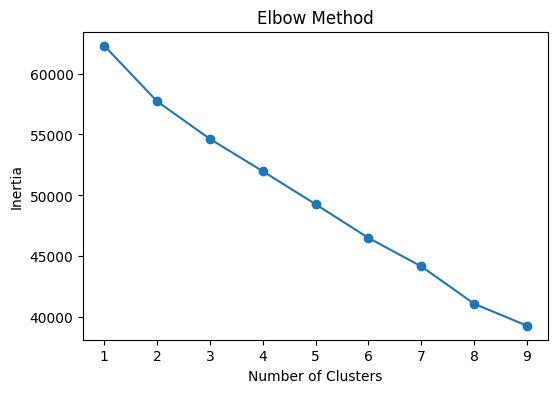

In [14]:
inertia = []

K = range(1,10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))

plt.plot(K, inertia, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

In [15]:
kmeans = KMeans(n_clusters=5, random_state=42)

movies['kmeans_cluster'] = kmeans.fit_predict(X)

movies[['title','rating','popularity','kmeans_cluster']].head()

,title,rating,popularity,kmeans_cluster
0,Heat,3.593750,17.924927,0
1,GoldenEye,1.500000,14.686036,4
2,Cutthroat Island,3.616279,7.284477,4
3,Casino,3.555556,10.137389,0
4,Sense and Sensibility,5.000000,10.673167,1


In [16]:
hc = AgglomerativeClustering(n_clusters=5)

movies['hierarchical_cluster'] = hc.fit_predict(X)

movies[['title','hierarchical_cluster']].head()

,title,hierarchical_cluster
0,Heat,1
1,GoldenEye,1
2,Cutthroat Island,1
3,Casino,1
4,Sense and Sensibility,0


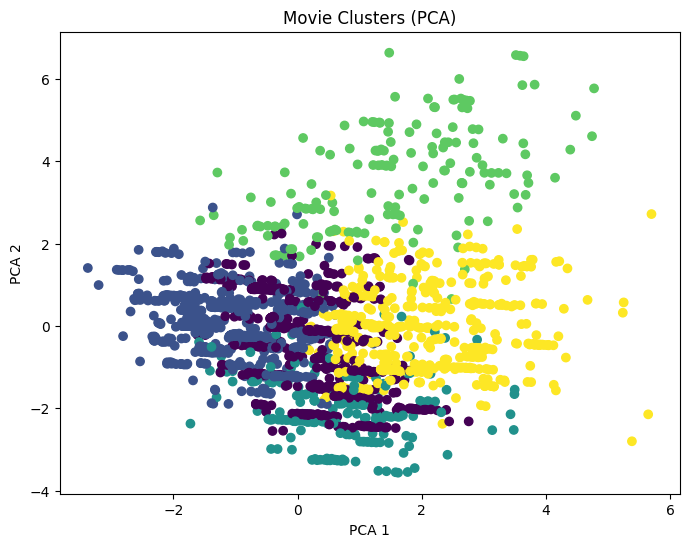

In [17]:
pca = PCA(n_components=2)

pca_result = pca.fit_transform(X)

plt.figure(figsize=(8,6))

plt.scatter(
    pca_result[:,0],
    pca_result[:,1],
    c=movies['kmeans_cluster']
)

plt.title("Movie Clusters (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

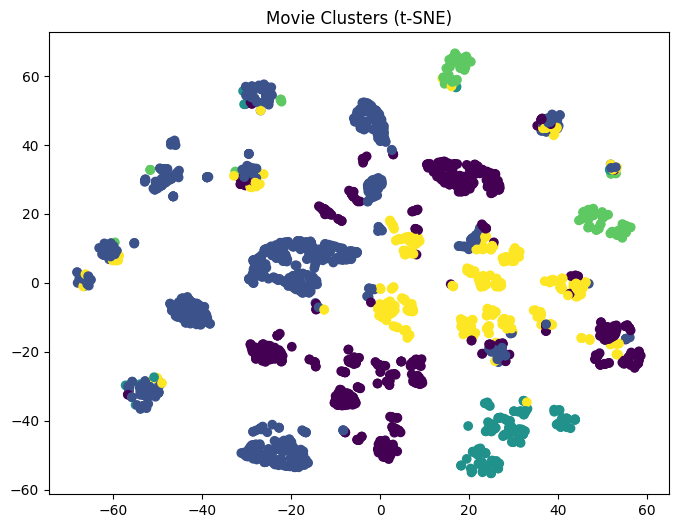

In [18]:
tsne = TSNE(n_components=2, random_state=42)

tsne_result = tsne.fit_transform(X)

plt.figure(figsize=(8,6))

plt.scatter(
    tsne_result[:,0],
    tsne_result[:,1],
    c=movies['kmeans_cluster']
)

plt.title("Movie Clusters (t-SNE)")

plt.show()

In [19]:
for i in range(5):

    print("\nCluster", i)

    print(movies[movies['kmeans_cluster']==i]['title'].head(10))


Cluster 0
0                       Heat
3                     Casino
5                 Four Rooms
6                 Get Shorty
11                To Die For
13              French Twist
14       From Dusk Till Dawn
17              Nick of Time
20               Taxi Driver
21    Flirting with Disaster
Name: title, dtype: object

Cluster 1
4             Sense and Sensibility
7                 Leaving Las Vegas
10                 Dead Man Walking
15                   Antonia's Line
16               Angels and Insects
19    The Bridges of Madison County
23                        Apollo 13
25                   Beyond Rangoon
28                            Crumb
35                   Before Sunrise
Name: title, dtype: object

Cluster 2
9              Twelve Monkeys
18              Unforgettable
30          Lord of Illusions
31                    The Net
38                 Disclosure
53          Three Colors: Red
54         Three Colors: Blue
73    In the Mouth of Madness
79             Color of

In [21]:
movies.to_csv("clustered_movies.csv", index=False)

In [23]:
movies.head()

,id,title,genres,popularity,rating,kmeans_cluster,hierarchical_cluster
0,949,Heat,"[Action, Crime, Drama, Thriller]",17.924927,3.593750,0,1
1,710,GoldenEye,"[Adventure, Action, Thriller]",14.686036,1.500000,4,1
2,1408,Cutthroat Island,"[Action, Adventure]",7.284477,3.616279,4,1
3,524,Casino,"[Drama, Crime]",10.137389,3.555556,0,1
4,4584,Sense and Sensibility,"[Drama, Romance]",10.673167,5.000000,1,0
